In [55]:
import pandas as pd

pcm=pd.read_csv("premierperu.csv")
inter=pd.read_pickle("inter.pkl")
edu=pd.read_pickle("edu.pkl")
salud=pd.read_pickle("salud.pkl")
mef=pd.read_pickle("mefall.pkl")


In [56]:
pcm.head()

,Titular,Partido,Gobierno,Militar,regime,Categoría,start,end
0,José María Raygada y Gallo,Militar,Ramón Castilla (II),1.0,constitutional,FIN_GOBIERNO,1857-02-14,1858-05-13
1,Manuel Ortiz de Zevallos y García,NaN,Ramón Castilla (II),NaN,constitutional,CAMBIO_GABINETE,1858-05-13,1858-07-13
2,Miguel de San Román y Meza,Militar,Ramón Castilla (II),1.0,constitutional,CAMBIO_GABINETE,1858-07-13,1858-10-24
3,Miguel del Carpio y Melgar,NaN,Ramón Castilla (II),NaN,constitutional,CAMBIO_GABINETE,1858-10-28,1860-06-09
4,Juan Antonio Pezet Rodríguez,Militar,Ramón Castilla (II),1.0,constitutional,CAMBIO_GABINETE,1860-06-09,1862-01-01


In [57]:
pcm.columns,inter.columns,edu.columns,salud.columns,mef.columns

(Index(['Titular', 'Partido', 'Gobierno', 'Militar', 'regime', 'Categoría',
        'start', 'end'],
       dtype='object'),
 Index(['Nombre', 'Presidente', 'Inicio', 'Fin', 'Partido', 'fecha_start',
        'fecha_end', 'cartera'],
       dtype='object'),
 Index(['Nombre', 'Partido', 'Presidente', 'Inicio', 'Fin', 'currentEdu',
        'fecha_start', 'fecha_end', 'cartera'],
       dtype='object'),
 Index(['Nombre', 'Partido', 'Presidente', 'Inicio', 'Fin', 'fecha_start',
        'fecha_end', 'cartera'],
       dtype='object'),
 Index(['Nombre', 'Partido', 'Presidente', 'fecha_start', 'fecha_end',
        'cartera'],
       dtype='object'))

In [58]:
pcm.rename(columns={'start':'fecha_start', 'end':'fecha_end','Gobierno':"Presidente",'Titular':'Nombre'},inplace=True)
pcm['cartera']='PCM'

In [59]:
sectores=pd.concat([pcm,inter,edu,salud,mef],ignore_index=True)

sectores.drop(columns=['regime','currentEdu','Militar',	'Categoría'],inplace=True)

sectores.drop(columns=['Inicio','Fin'],inplace=True)

In [60]:
sectores

,Nombre,Partido,Presidente,fecha_start,fecha_end,cartera
0,José María Raygada y Gallo,Militar,Ramón Castilla (II),1857-02-14,1858-05-13,PCM
1,Manuel Ortiz de Zevallos y García,NaN,Ramón Castilla (II),1858-05-13,1858-07-13,PCM
2,Miguel de San Román y Meza,Militar,Ramón Castilla (II),1858-07-13,1858-10-24,PCM
3,Miguel del Carpio y Melgar,NaN,Ramón Castilla (II),1858-10-28,1860-06-09,PCM
4,Juan Antonio Pezet Rodríguez,Militar,Ramón Castilla (II),1860-06-09,1862-01-01,PCM
...,...,...,...,...,...,...
1064,José Salardi Rodríguez,Independiente,Dina Boluarte,2025-01-31 00:00:00,2025-05-13 00:00:00,MEF
1065,Raúl Pérez-Reyes Espejo,Independiente,Dina Boluarte,2025-05-13 00:00:00,2025-10-10 00:00:00,MEF
1066,Denisse Miralles Miralles,Independiente,José Jerí,2025-10-14 00:00:00,2026-02-17 00:00:00,MEF
1067,Gerardo López Gonzales,Independiente,José María Balcázar,2026-02-24 00:00:00,2026-03-17 00:00:00,MEF


In [61]:
sectores[sectores.fecha_start>sectores.fecha_end]

,Nombre,Partido,Presidente,fecha_start,fecha_end,cartera


In [62]:
sectores.cartera.value_counts()

cartera
MEF          298
Interior     242
PCM          232
Educacion    213
salud         84
Name: count, dtype: int64

In [63]:
sectores.to_csv('sectores_all.csv',index=False)

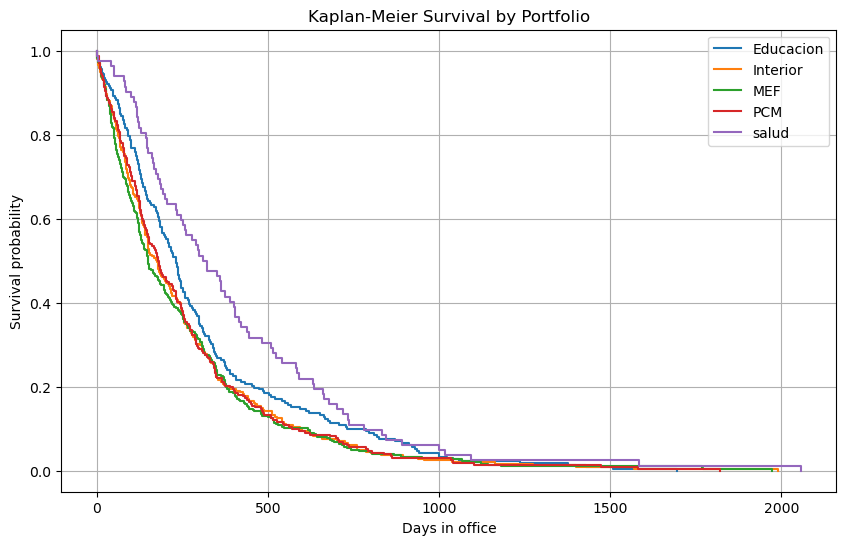

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

df = sectores.copy()

df["fecha_start"] = pd.to_datetime(df["fecha_start"])
df["fecha_end"] = pd.to_datetime(df["fecha_end"])

df["duration"] = (df["fecha_end"] - df["fecha_start"]).dt.days
df["event"] = 1

df = df.dropna(subset=["duration", "cartera"])
df = df[df["duration"] >= 0]

kmf = KaplanMeierFitter()

plt.figure(figsize=(10, 6))

for cartera in sorted(df["cartera"].unique()):
    temp = df[df["cartera"] == cartera]
    
    kmf.fit(
        durations=temp["duration"],
        event_observed=temp["event"],
        label=cartera
    )
    
    kmf.plot_survival_function(ci_show=False)

plt.title("Kaplan-Meier Survival by Portfolio")
plt.xlabel("Days in office")
plt.ylabel("Survival probability")
plt.grid(True)
plt.show()

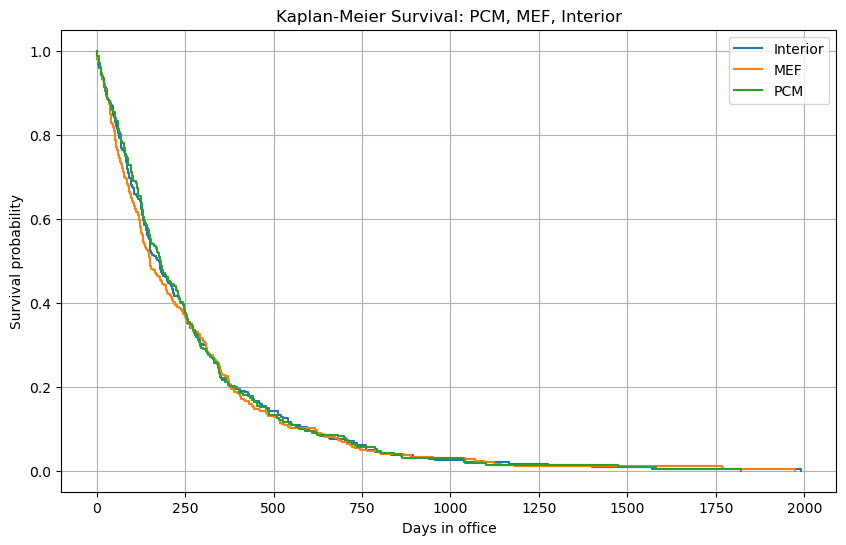

In [65]:
focus = df[df["cartera"].isin(["PCM", "MEF", "Interior"])]

plt.figure(figsize=(10, 6))

for cartera in sorted(focus["cartera"].unique()):
    temp = focus[focus["cartera"] == cartera]
    
    kmf.fit(
        durations=temp["duration"],
        event_observed=temp["event"],
        label=cartera
    )
    
    kmf.plot_survival_function(ci_show=False)

plt.title("Kaplan-Meier Survival: PCM, MEF, Interior")
plt.xlabel("Days in office")
plt.ylabel("Survival probability")
plt.grid(True)
plt.show()

In [66]:
test = multivariate_logrank_test(
    focus["duration"],
    focus["cartera"],
    focus["event"]
)

print(test.summary)

   test_statistic         p  -log2(p)
0        0.286301  0.866624  0.206523


In [67]:
for cartera in sorted(focus["cartera"].unique()):
    temp = focus[focus["cartera"] == cartera]
    kmf.fit(temp["duration"], temp["event"])
    print(cartera, kmf.median_survival_time_)

Interior 177.0
MEF 150.0
PCM 180.0


In [72]:
df_1993 = df[df["fecha_start"].dt.year >= 1993].copy()

focus_1993 = df_1993[df_1993["cartera"].isin(["PCM", "MEF", "Interior"])].copy()

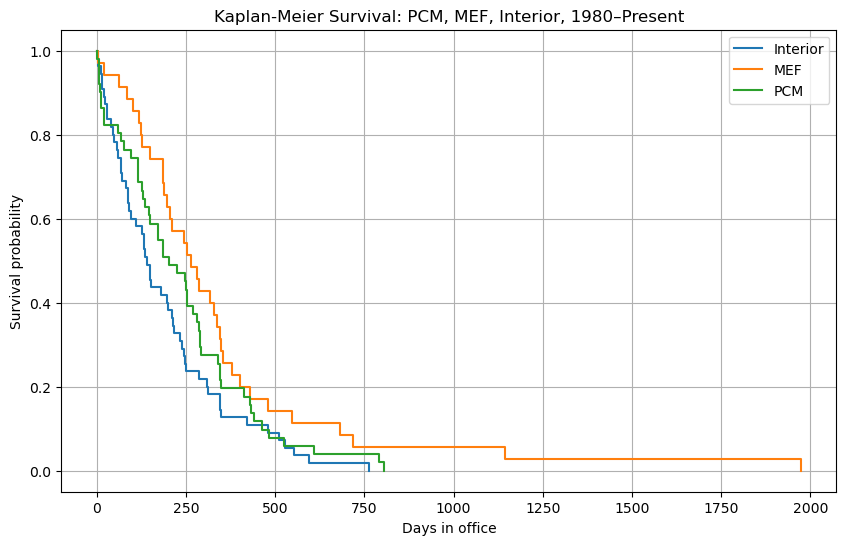

In [73]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(10, 6))

for cartera in sorted(focus_1993["cartera"].unique()):
    temp = focus_1993[focus_1993["cartera"] == cartera]
    
    kmf.fit(
        durations=temp["duration"],
        event_observed=temp["event"],
        label=cartera
    )
    
    kmf.plot_survival_function(ci_show=False)

plt.title("Kaplan-Meier Survival: PCM, MEF, Interior, 1980–Present")
plt.xlabel("Days in office")
plt.ylabel("Survival probability")
plt.grid(True)
plt.show()

In [75]:
test_1993 = multivariate_logrank_test(
    focus_1993["duration"],
    focus_1993["cartera"],
    focus_1993["event"]
)

print(test_1993.summary)

   test_statistic         p  -log2(p)
0         6.84669  0.032603  4.938843


In [76]:
for cartera in sorted(focus_1993["cartera"].unique()):
    temp = focus_1993[focus_1993["cartera"] == cartera]
    kmf.fit(temp["duration"], temp["event"])
    print(cartera, kmf.median_survival_time_)

Interior 141.0
MEF 264.0
PCM 203.0
